# IPO Market Gains

### Table of Contents

### Intro

When a company decides to go public, it embarks on a complex financial journey that transforms its ownership and market valuation. Through an initial public offering (IPO), the company works with investment banks to set an initial stock price that reflects its perceived value. However, the true test comes on the first day of public trading, when investors' collective judgment determines the stock's actual worth. This moment can result in a listing gain, where the stock price rises above the initial offering price, signify a neutral market response, or even experience a price decline, depending on investor confidence, market conditions, and the company's perceived potential.

In this project, we will build a deep learning model that predicts weather or not a business in the Indian Market will have positive listing gains. Our goal is to exemplify some of the very useful things pytorch and deep learning models can do for us and to demonstrate the different tools we can use to help our model be more accurate. We will be using a dataset is based off of [moneycontrol](https://www.moneycontrol.com/ipo/listed-ipos/?classic=true). It consists details from former IPOs in the Indian market. 

### Set Up

First things first, in the code below, we will import our libraries and bring in our data.

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix
import copy

In [2]:
df = pd.read_csv('Indian_IPO_Market_Data.csv')

### Intial Exploration

With our libraries and data now ready, we will do some exploring and make our first observations of the data in the code below.

In [3]:
df

,Date,IPOName,Issue_Size,Subscription_QIB,Subscription_HNI,Subscription_RII,Subscription_Total,Issue_Price,Listing_Gains_Percent
0,03/02/10,Infinite Comp,189.80,48.44,106.02,11.08,43.22,165,11.82
1,08/02/10,Jubilant Food,328.70,59.39,51.95,3.79,31.11,145,-84.21
2,15/02/10,Syncom Health,56.25,0.99,16.60,6.25,5.17,75,17.13
3,15/02/10,Vascon Engineer,199.80,1.12,3.65,0.62,1.22,165,-11.28
4,19/02/10,Thangamayil,0.00,0.52,1.52,2.26,1.12,75,-5.20
...,...,...,...,...,...,...,...,...,...
314,26/08/22,Syrma SGS,840.13,42.42,7.13,2.84,15.59,220,42.30
315,06/09/22,Dreamfolks Serv,562.10,27.48,14.18,24.19,23.25,326,41.92
316,15/09/22,TMB,792.00,0.51,1.77,3.44,1.39,525,-3.15
317,26/09/22,Harsha Engineer,755.00,113.82,40.36,12.44,47.19,330,47.24


**`df` – Observations:**

* There are **319** rows and **9** columns.
* We can observe a few categorical columns.
* The values in the `IPOName` column suggest that there are IPOs from lots of different genres of companies
* The `date` column is in the format Day/Month/Year
* We do not notice any empty or 'NaN' values. 

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 319 entries, 0 to 318
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Date                   319 non-null    object 
 1   IPOName                319 non-null    object 
 2   Issue_Size             319 non-null    float64
 3   Subscription_QIB       319 non-null    float64
 4   Subscription_HNI       319 non-null    float64
 5   Subscription_RII       319 non-null    float64
 6   Subscription_Total     319 non-null    float64
 7   Issue_Price            319 non-null    int64  
 8   Listing_Gains_Percent  319 non-null    float64
dtypes: float64(6), int64(1), object(2)
memory usage: 22.6+ KB


**`df.info()` – Observations:**

* There are **2** object columns, **1** integer column, and **6** float columns.
* As we suspected, there are no missing values.

In [5]:
df.describe()

,Issue_Size,Subscription_QIB,Subscription_HNI,Subscription_RII,Subscription_Total,Issue_Price,Listing_Gains_Percent
count,319.000000,319.000000,319.000000,319.000000,319.000000,319.000000,319.000000
mean,1192.859969,25.684138,70.091379,8.561599,27.447147,375.128527,4.742696
std,2384.643786,40.716782,142.454416,14.508670,48.772203,353.897614,47.650946
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-97.150000
25%,169.005000,1.150000,1.255000,1.275000,1.645000,119.000000,-11.555000
50%,496.250000,4.940000,5.070000,3.420000,4.930000,250.000000,1.810000
75%,1100.000000,34.635000,62.095000,8.605000,33.395000,536.000000,25.310000
max,21000.000000,215.450000,958.070000,119.440000,326.490000,2150.000000,270.400000


**`df.describe()` – Observations:**

* There do not appear to be any binary columns.
* All the columns have reasonable, and sometimes even large `std` values, telling us that they all have decent and wide distributions.
* All of the `50%` (median) values are lower than the `mean` values showing us that there are some large values in each column, but also enough modest values to pull the median down.

So far, our observations have shown us that our dataset is looking like it will work very well in our upcoming model. Let's continue getting to know our model by looking at the column definitions.

In [6]:
df.columns

Index(['Date ', 'IPOName', 'Issue_Size', 'Subscription_QIB',
       'Subscription_HNI', 'Subscription_RII', 'Subscription_Total',
       'Issue_Price', 'Listing_Gains_Percent'],
      dtype='object')

### Dataset Column Definitions<a id="def"></a>

1. **Date** – date when the IPO was listed
2. **IPOName** – name of the IPO
3. **Issue_Size** – size of the IPO issue, in INR Crores
4. **Subscription_QIB** – number of times the IPO was subscribed by QIB (Qualified Institutional Buyer) investors
5. **Subscription_HNI** – number of times the IPO was subscribed by HNI (High Networth Individual) investors
6. **Subscription_RII** – number of times the IPO was subscribed by RII (Retail Individual Investors)
7. **Subscription_Total** – total number of times the IPO was subscribed overall
8. **Issue_Price** – the price in INR at which the IPO was issued
9. **Listing_Gains_Percent** – percentage gain in the listing price over the issue price

### Further Exploration

Now that we've been familarizing ourselves with the dataset, we want to dive in a bit deeper. If we were in the position of an investor company, the main thing we care about when looking at an IPO is if it will be profitable or not. This is essentially what we will be trying to predict in our model later on. With this goal in mind, our next step of exploration will be to see how many instances in our dataset were profitable and how many were not. In the code below, we will filter the `Listing_Gains_Percent` column to form a new column that categorizes each instance as profitable or not. This new column will end up being our target label in our model. We will also initiate a copy of our original dataframe, that we will save all our changes to. This is to preserve our original dataframe, incase we need it in it's original form later.

In [7]:
df_clean = df.copy()
df_clean['Listing_Gains_Profit'] = (df_clean['Listing_Gains_Percent'] > 0).astype(int)

In [8]:
profitable = df_clean['Listing_Gains_Profit'].value_counts(normalize=True)[1] * 100
not_profitable = df_clean['Listing_Gains_Profit'].value_counts(normalize=True)[0] * 100

print(f"Percentage of profitable IPOs (1): {profitable:.2f}%")
print(f"Percentage of unprofitable IPOs (0): {not_profitable:.2f}%")

Percentage of profitable IPOs (1): 54.55%
Percentage of unprofitable IPOs (0): 45.45%


As we can see from the results above, our data is close to half profitable and half unprofitable. This is good news for us, as it will make the work easier for our model later. This also tells us that we're working with a confident market, where investors are generally willing to make a positive gain offer.

Next, we want to look at what the average positive gain and negative loss is. In other words, how much are investors generally offereing on the positive side, versus the negative side. We will also look at the largest positive gain, and the largest negative loss.

In [9]:
gain_avg = df_clean[df_clean['Listing_Gains_Profit'] == 1]['Listing_Gains_Percent'].mean()
loss_avg = df_clean[df_clean['Listing_Gains_Profit'] == 0]['Listing_Gains_Percent'].mean()

gain_max = df_clean[df_clean['Listing_Gains_Profit'] == 1]['Listing_Gains_Percent'].max()
loss_min = df_clean[df_clean['Listing_Gains_Profit'] == 0]['Listing_Gains_Percent'].min()

In [10]:
print(f"Average positive gain: {gain_avg:.2f}%")
print(f"Average negative loss: {loss_avg:.2f}%")
print("\n")
print(f"Greatest gain: {gain_max:.2f}%")
print(f"Greatest loss: {loss_min:.2f}%")

Average positive gain: 33.99%
Average negative loss: -30.36%


Greatest gain: 270.40%
Greatest loss: -97.15%


### Feature Selection - Cleaning

From all that we've observed in our exploration, our data seems to be very clean and orderly. We noticed no major errors that needed to be addressed other than building the `Listing_Gains_Profit` column (our new target) from the `Listing_Gains_Percent` column. That being said, we want to dive right into the preliminary steps we need to take that contribute towards the making of our model. Our first move will be to start examining our columns through the lense of feature selection. In this next phase, we will be examining distributions and correlations in order to determine which columns we will select to be features in our model. Since we will strive to have as accurate a model as possible, it begins with our features. We want to select the features that will give our model the best chance to be accurate, without overloading the model with useless information.

Before we dive into examining the distributions of our columns, we need to deal with out two object datatype columns. These columns, `Date ` and `IPOName`, contian text. They need to be converted to numeric values so we can evaluate them. We can see right away that the `` column not only will be difficult to convert to numeric values, but the information itself is not highly valueable to determining profit outcomes. We decide to drop this column in the code below.

In [11]:
df_clean = df_clean.drop(columns=['IPOName'])

Next, we want to deal with the `Date ` column.

In [12]:
df_clean['Date ']

0      03/02/10
1      08/02/10
2      15/02/10
3      15/02/10
4      19/02/10
         ...   
314    26/08/22
315    06/09/22
316    15/09/22
317    26/09/22
318    17/10/22
Name: Date , Length: 319, dtype: object

As it is, the data in this column once again does not seem to hold a large amount of value to our target, since there is no exact day/month/year that repeats itself. However, instead of dropping this column like we did with the last one, we will extract two different aspects from the `Date ` column that could hold siginificant value for our model. We will extract the day of the week that each date occured on, and the month of each date. Since these things repeat themselves every week, and every year, they just might contain enough correlational value to be included in our model. In the code below, we will create two new columns, `day_of_week` and `month_of_year`. Then, we will drop the original `Date ` column. Finally, we will convert our two new columns into dummy variables. Dummy variables convert the values of object columns into numbers by creating new columns for each unique value in the original column. In these new columns, a 1 indicates that the row belongs to that category, while a 0 indicates that it does not. This format makes the data easier for the program to understand and use when building a model.

In [13]:
df_clean['clean_date'] = pd.to_datetime(df_clean['Date '], format='mixed', dayfirst=True)

In [14]:
df_clean['day_of_week'] = df_clean['clean_date'].dt.day_name()

In [15]:
df_clean['day_of_week']

0      Wednesday
1         Monday
2         Monday
3         Monday
4         Friday
         ...    
314       Friday
315      Tuesday
316     Thursday
317       Monday
318       Monday
Name: day_of_week, Length: 319, dtype: object

In [16]:
df_clean['month_of_year'] = df_clean['clean_date'].dt.month_name()

In [17]:
df_clean['month_of_year']

0       February
1       February
2       February
3       February
4       February
         ...    
314       August
315    September
316    September
317    September
318      October
Name: month_of_year, Length: 319, dtype: object

In [18]:
# Drop original Date column and clean_date column
df_clean = df_clean.drop(columns=['Date '])
df_clean = df_clean.drop(columns=['clean_date'])

# Convert the selected columns into dummy variables
day_dummies = pd.get_dummies(df_clean['day_of_week'], prefix='')
day_dummies = day_dummies.astype(int)

month_dummies = pd.get_dummies(df_clean['month_of_year'], prefix='')
month_dummies = month_dummies.astype(int)

# Joining the original df and the dummies df
df_clean = pd.concat([df_clean, day_dummies], axis=1)
df_clean = pd.concat([df_clean, month_dummies], axis=1)

# Drop all the original columns
df_clean = df_clean.drop(columns=['day_of_week'])
df_clean = df_clean.drop(columns=['month_of_year'])

In [19]:
# Reorganizing the columns
new_order = ['Issue_Size', 'Subscription_QIB', 'Subscription_HNI', 'Subscription_RII', 'Subscription_Total', 'Issue_Price', 'Listing_Gains_Percent', 'Listing_Gains_Profit', '_Monday', '_Tuesday', '_Wednesday', '_Thursday', '_Friday', '_January', '_February', '_March', '_April', '_May', '_June', '_July', '_August', '_September', '_October', '_November', '_December']

df_clean = df_clean.reindex(columns=new_order)

We have now dealt with all the non-numeric values. Next, we're going to drop the `Listing_Gains_Percent` column. If you recall, it was our original target column, before we made the `Listing_Gains_Profit` column. Since our new target column was based off of the `Listing_Gains_Percent` column, it would be cheating to allow our model to use it.

In [20]:
df_clean = df_clean.drop(columns=['Listing_Gains_Percent'])

In [21]:
pd.set_option('display.max_columns', None)
df_clean

,Issue_Size,Subscription_QIB,Subscription_HNI,Subscription_RII,Subscription_Total,Issue_Price,Listing_Gains_Profit,_Monday,_Tuesday,_Wednesday,_Thursday,_Friday,_January,_February,_March,_April,_May,_June,_July,_August,_September,_October,_November,_December
0,189.80,48.44,106.02,11.08,43.22,165,1,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0
1,328.70,59.39,51.95,3.79,31.11,145,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0
2,56.25,0.99,16.60,6.25,5.17,75,1,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0
3,199.80,1.12,3.65,0.62,1.22,165,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0
4,0.00,0.52,1.52,2.26,1.12,75,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
314,840.13,42.42,7.13,2.84,15.59,220,1,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0
315,562.10,27.48,14.18,24.19,23.25,326,1,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0
316,792.00,0.51,1.77,3.44,1.39,525,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0
317,755.00,113.82,40.36,12.44,47.19,330,1,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0


In [22]:
pd.reset_option('display.max_columns')

At last, we are ready to examine the distributions of our feature canidates. In the code below, we will split our features into two sections, the first part being the first 6 columns in our dataframe, and the second part being all the dummy variable columns. Then, we will visualize the distributions of each group seperately, and make our observations.

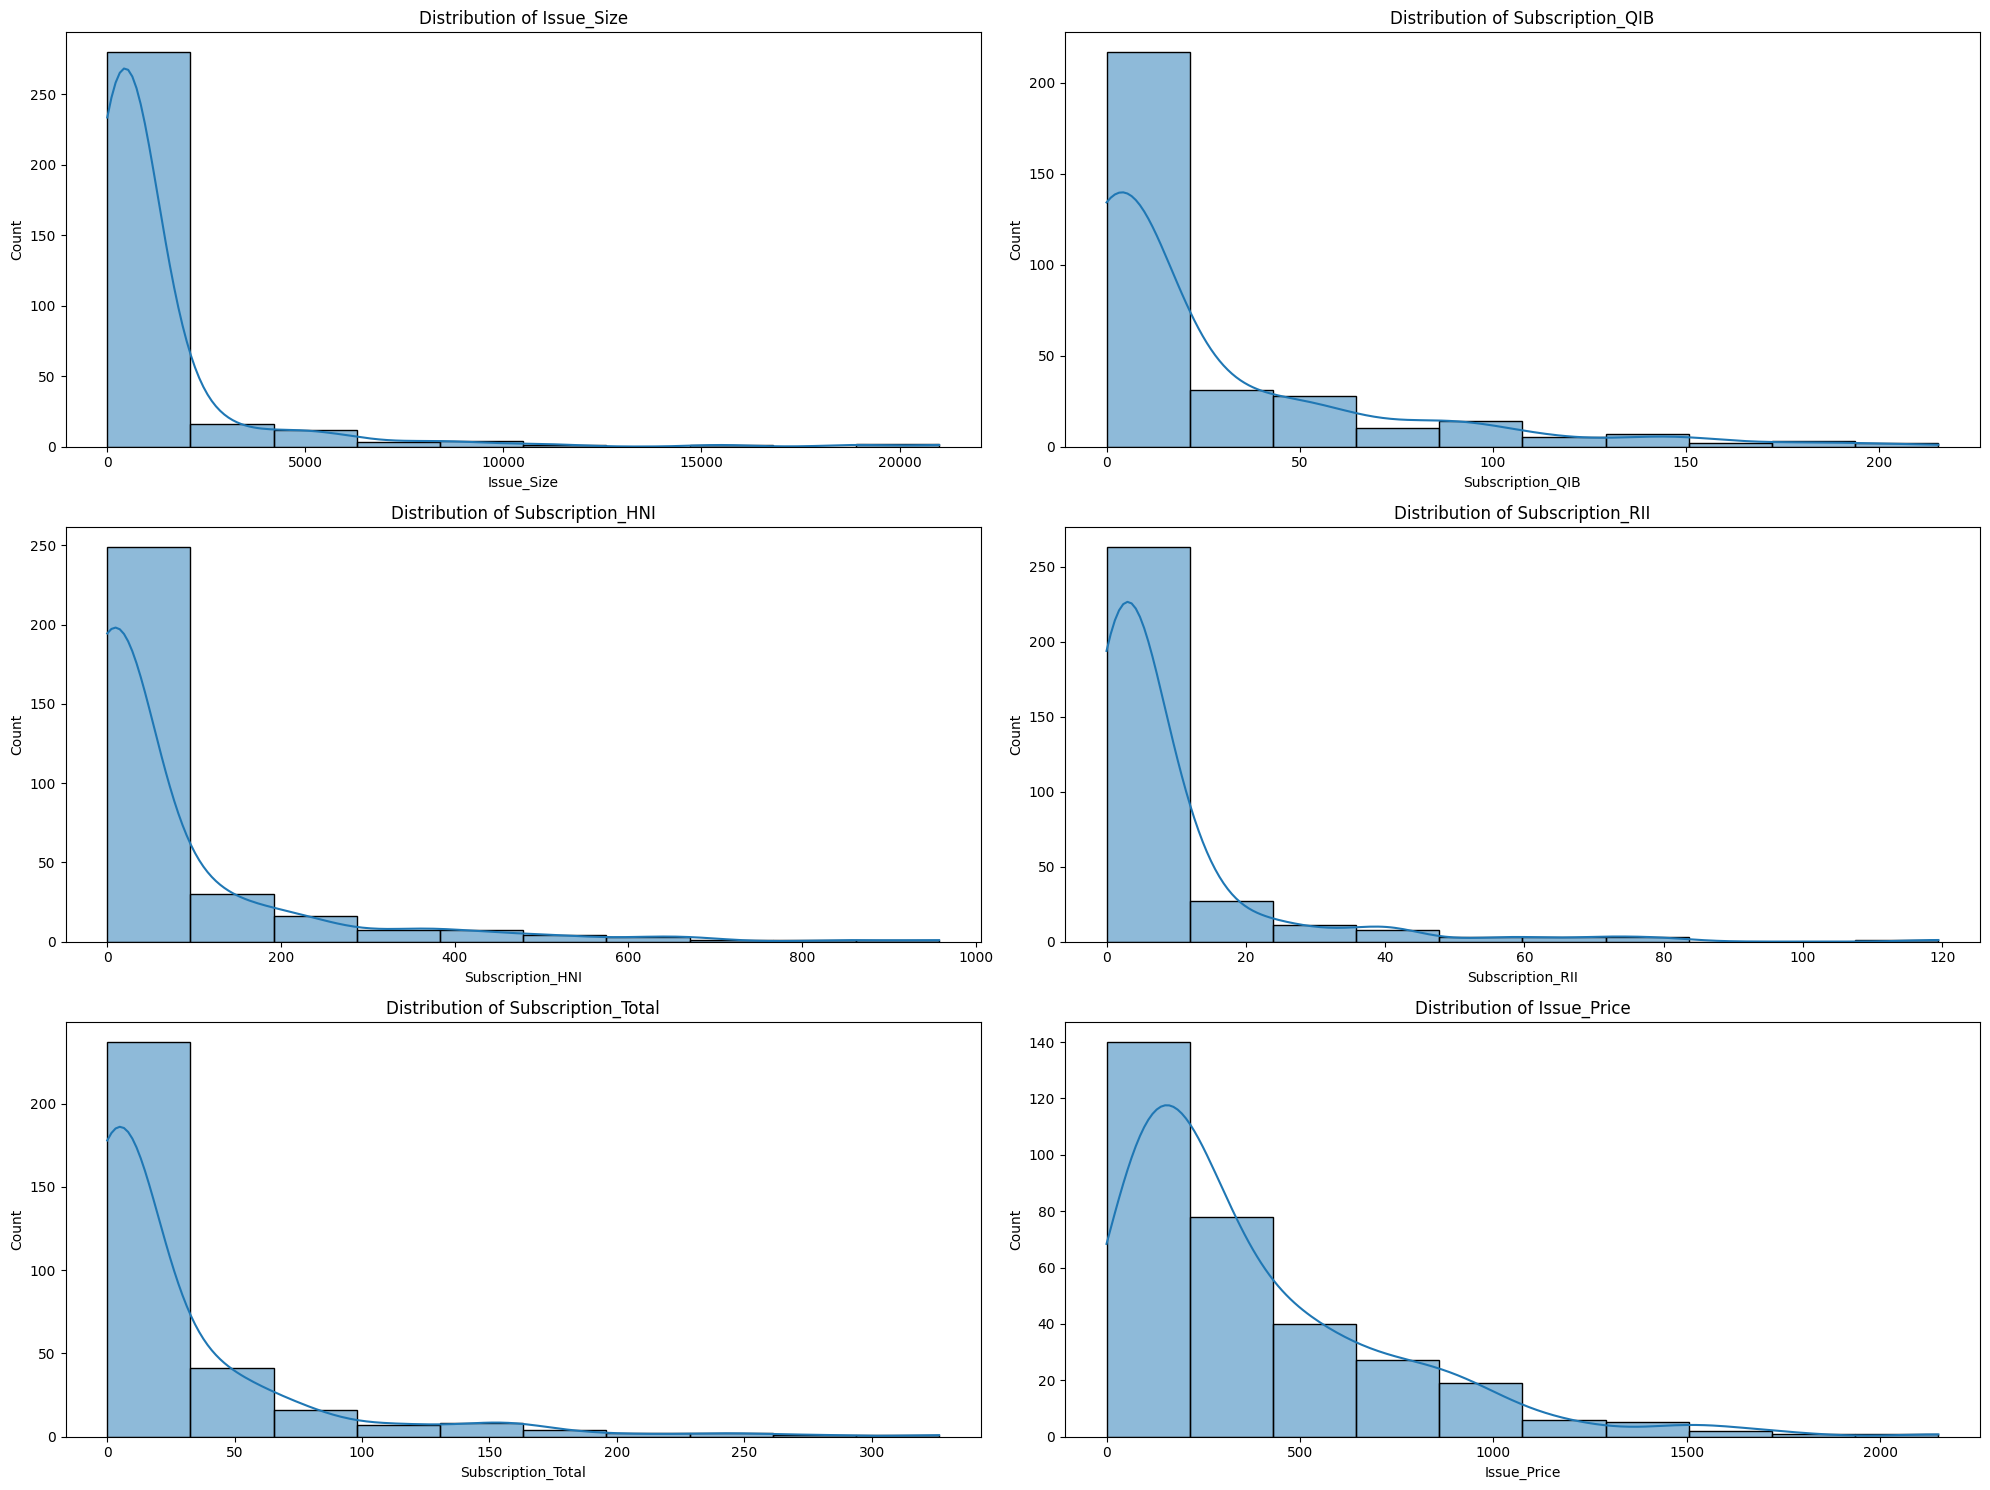

In [23]:
distribution_pt1 = df_clean[['Issue_Size', 'Subscription_QIB', 'Subscription_HNI', 'Subscription_RII', 'Subscription_Total', 'Issue_Price']]

n_rows = 3
n_cols = 2

# generating first group distribution visualization
fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 15))
axes = axes.flatten()

for i, col in enumerate(distribution_pt1.columns):
    if distribution_pt1[col].dtype == 'object' or distribution_pt1[col].nunique() < 6:  # Check for categorical data
        sns.countplot(data=distribution_pt1, x=col, ax=axes[i])
    else:
        sns.histplot(data=distribution_pt1, x=col, ax=axes[i], bins=10, kde=True)

    axes[i].set_title(f'Distribution of {col}')

for j in range(i + 1, n_rows * n_cols):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

The repeated pattern in the distributions above shows us that the majority of IPOs have low subscription amounts, smaller issue sizes, and medium issue prices, while each category has a few extremely high values. While this helps us better understand more details of the IPO market in India, these high values (outliers) and lopsided (skewed) distributions would not do well in our model. Our model would get so distracted by the abnormally high values, that it would miss the relationships between the lower scale values which make up the majority of the data. To prevent this, we will simply scale our these features, which helps to balance out the larger values, compared to the smaller ones.

Now, let's take a look at the distributions of our dummy variables for weekdays and months.

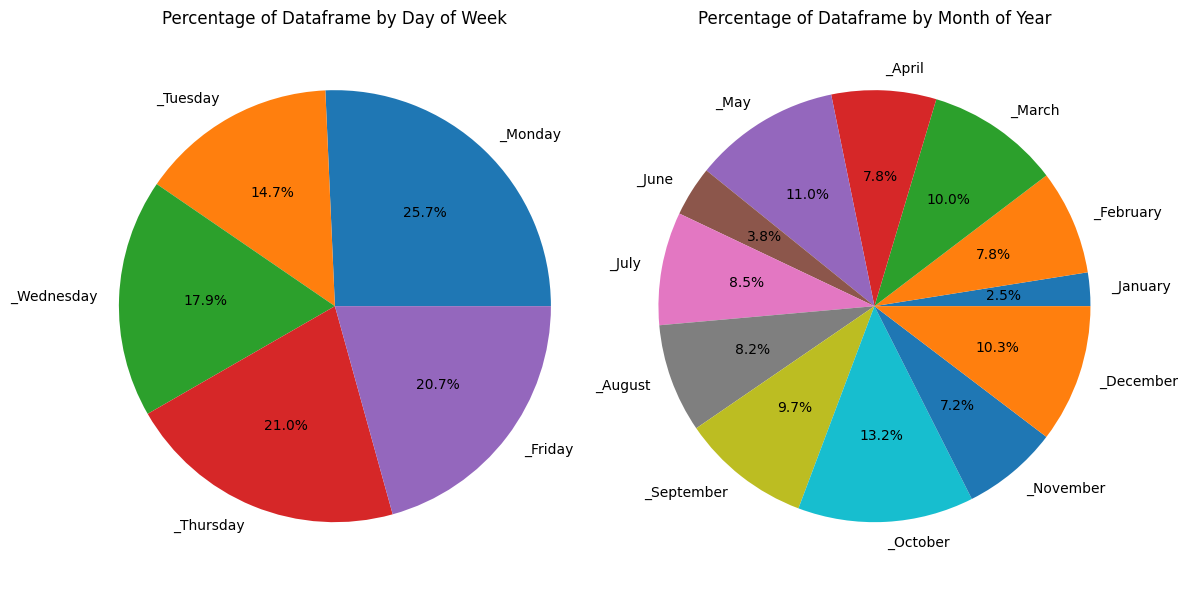

In [24]:
day_columns = ['_Monday', '_Tuesday', '_Wednesday', '_Thursday', '_Friday']
day_percentages = df_clean[day_columns].sum() / len(df) * 100

month_columns = ['_January', '_February', '_March', '_April', '_May', '_June', '_July', '_August', '_September', '_October', '_November', '_December']
month_percentages = df_clean[month_columns].sum() / len(df) * 100

# Create a figure and axis
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))

# First pie chart
ax1.pie(day_percentages, labels=day_percentages.index, autopct='%1.1f%%')
ax1.set_title('Percentage of Dataframe by Day of Week')

# Second pie chart
ax2.pie(month_percentages, labels=month_percentages.index, autopct='%1.1f%%')
ax2.set_title('Percentage of Dataframe by Month of Year')

# Ensure the pie charts are drawn as circles
ax1.axis('equal')
ax2.axis('equal')

# Adjust layout and display the plot
plt.tight_layout()
plt.show()

In examining the outcome above, we notice that there indeed are certain weekdays and months that occur more than others. We can see that Monday holds the highest percentage in the weekday category, while October holds the highest percentage in the month category. This helps us to see times of the week and year that might be more prone to have IPO listings.

These distribution visualizations have given us a good idea of what our features are doing across the dataset. Next, we want to look at what our feature are doing when the IPO results in positive gain versus when it results in a negative loss. Once again, we are going to visualize the two halves of our data seprately, and make our observations after each one. Let's start with visualizing our first group of featues across gains and losses in the code below.

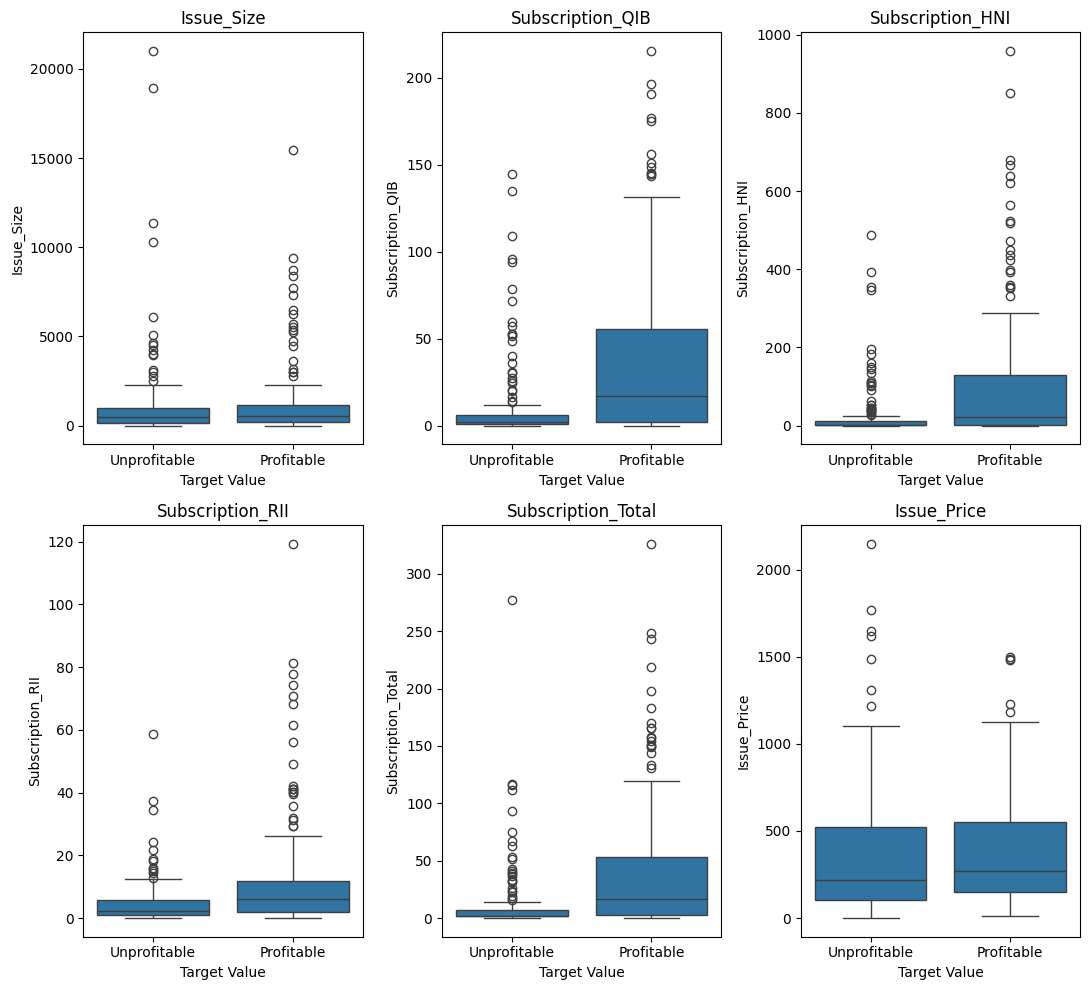

In [25]:
def create_boxplot_grid(df, columns, target_column):
    # Number of columns in the plot grid
    n_cols = 3  # Fixed to 3 columns
    n_rows = 2  # Fixed to 2 rows
    
    # Create the figure and subplots
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(11, 10))
    
    # Flatten the axes for easier indexing
    axes = axes.flatten()
    
    # Create box plots for each feature
    for i, column in enumerate(columns):
        # Create a dataframe with the feature and target
        plot_data = pd.DataFrame({
            'Value': df[column],
            'Target': df[target_column]
        })
        
        # Create the box plot
        sns.boxplot(x='Target', y='Value', data=plot_data, ax=axes[i])
        
        # Set title and labels
        axes[i].set_title(f'{column}')
        axes[i].set_xlabel('Target Value')
        axes[i].set_ylabel(column)
        axes[i].set_xticks([0, 1])
        axes[i].set_xticklabels(['Unprofitable', 'Profitable'])
    
    # Adjust layout
    plt.tight_layout()
    plt.show()


create_boxplot_grid(df_clean, ['Issue_Size', 'Subscription_QIB', 'Subscription_HNI', 'Subscription_RII', 'Subscription_Total', 'Issue_Price'], 'Listing_Gains_Profit')

Throughout all our observations up to this point, the data has slowly been painting a picture of the information it holds. Now, as we study the results above, we can see the details really start falling into place. We observe from the box plots of the `Issue_Size` and `Issue_Price` features, that the size and original price of an IPO doesn't matter when it comes to weather or not it will be profitable. The subscription features however, show us that the environment of the market is everything. If the investors are feeling excited about an IPO, it will be successful. The demeand and energy of the market, represented by the eagerness of investors to oversubscribe, will determine the outcome of gain or loss. This tells us that these features detailing different types of subscriptions will be very important to our model. If our model is able to learn the relationships between subscriptions and profitable IPOs, it's accuracy should boost significantly.

Next, we want to examine the day and month features. We will be looking at a pie chart once again, but this time we will be looking at the percetages of days and months when the IPO was profitable, and when it wasn't. This will help us to see if the market demand changes at all during different parts of a week or a year.

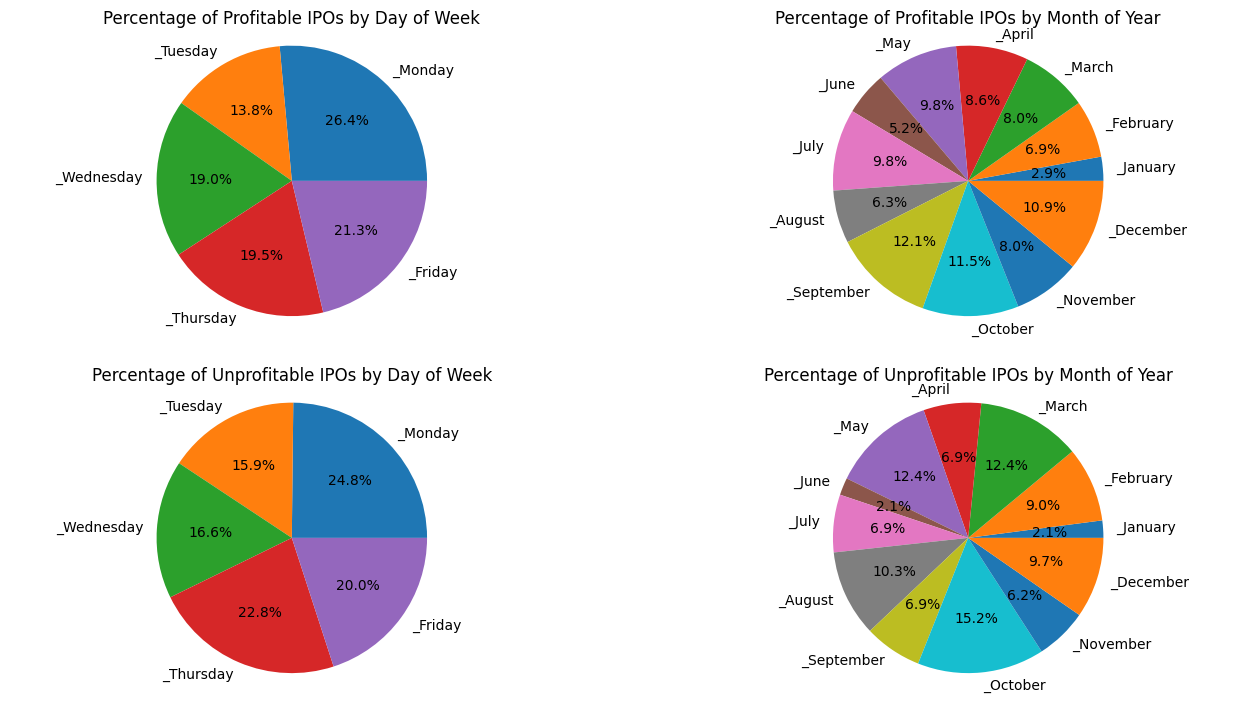

In [26]:
day_columns = ['_Monday', '_Tuesday', '_Wednesday', '_Thursday', '_Friday']
profitable_days = df_clean[df_clean['Listing_Gains_Profit'] == 1][day_columns]
profitable_day_percentages = profitable_days.sum() / len(df) * 100
unprofitable_days = df_clean[df_clean['Listing_Gains_Profit'] == 0][day_columns]
unprofitable_day_percentages = unprofitable_days.sum() / len(df) * 100

month_columns = ['_January', '_February', '_March', '_April', '_May', '_June', '_July', '_August', '_September', '_October', '_November', '_December']
profitable_months = df_clean[df_clean['Listing_Gains_Profit'] == 1][month_columns]
profitable_month_percentages = profitable_months.sum() / len(df) * 100
unprofitable_months = df_clean[df_clean['Listing_Gains_Profit'] == 0][month_columns]
unprofitable_month_percentages = unprofitable_months.sum() / len(df) * 100

# Create a figure and axis
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 8.5))

# First pie chart
ax1.pie(profitable_day_percentages, labels=profitable_day_percentages.index, autopct='%1.1f%%')
ax1.set_title('Percentage of Profitable IPOs by Day of Week')
ax1.axis('equal')

# Second pie chart
ax2.pie(profitable_month_percentages, labels=profitable_month_percentages.index, autopct='%1.1f%%')
ax2.set_title('Percentage of Profitable IPOs by Month of Year')
ax2.axis('equal')

# Third pie chart
ax3.pie(unprofitable_day_percentages, labels=unprofitable_day_percentages.index, autopct='%1.1f%%')
ax3.set_title('Percentage of Unprofitable IPOs by Day of Week')
ax3.axis('equal')

# Fourth pie chart
ax4.pie(unprofitable_month_percentages, labels=unprofitable_month_percentages.index, autopct='%1.1f%%')
ax4.set_title('Percentage of Unprofitable IPOs by Month of Year')
ax4.axis('equal')

# Adjust layout and display the plot
plt.show()

In [ ]:
# plotting percent distribution bar graphs per cluster
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# First plot - first categorical column
plot_df1 = pd.crosstab(index=df_clean['Listing_Gains_Profit'], 
                       columns=df_clean[day_columns], 
                       values=df_clean[day_columns], 
                       aggfunc='size', 
                       normalize='index')
plot_df1.plot.bar(stacked=True, ax=ax1, alpha=0.6)
ax1.set_title(f'% {categorical_columns[0].title()} per Cluster', alpha=0.5)
ax1.set_ylim(0, 1.4)
ax1.legend(frameon=False)
ax1.xaxis.grid(False)

labels = [0, 0.2, 0.4, 0.6, 0.8, 1]
ax1.set_yticks(labels)
ax1.set_yticklabels(labels)

# Second plot - second categorical column
plot_df2 = pd.crosstab(index=df_clean['Listing_Gains_Profit'], 
                       columns=df_clean[month_columns], 
                       values=df_clean[month_columns], 
                       aggfunc='size', 
                       normalize='index')
plot_df2.plot.bar(stacked=True, ax=ax2, alpha=0.6)
ax2.set_title(f'% {categorical_columns[1].title()} per Cluster', alpha=0.5)
ax2.set_ylim(0, 1.4)
ax2.legend(frameon=False)
ax2.xaxis.grid(False)

ax2.set_yticks(labels)
ax2.set_yticklabels(labels)

plt.tight_layout()
plt.show()

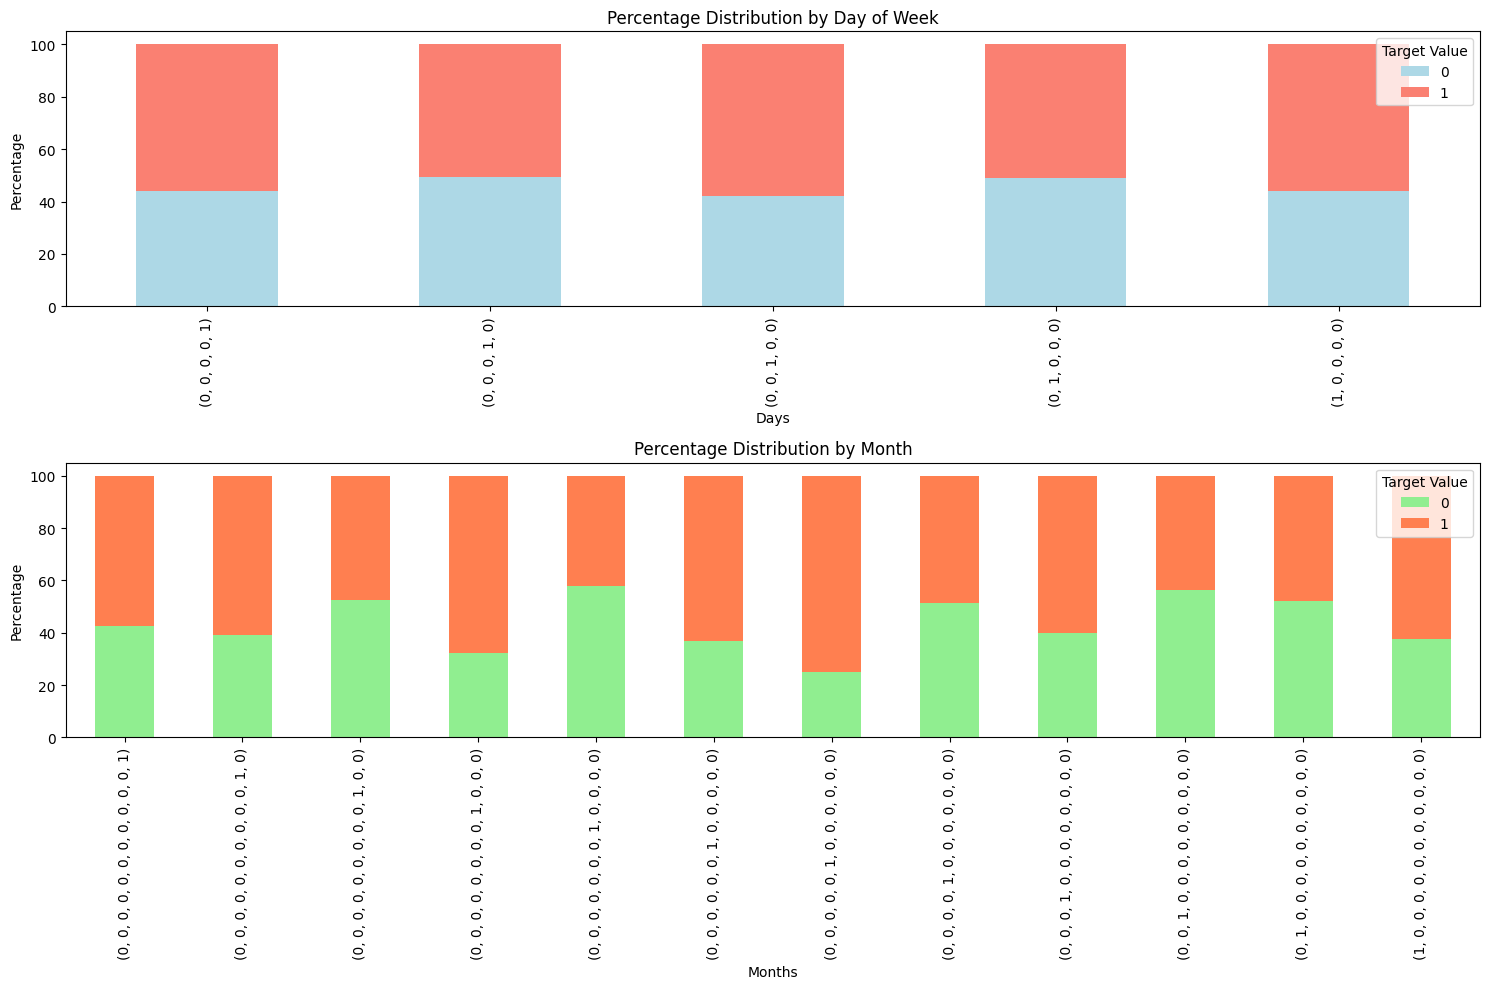

In [28]:
def create_stacked_percentage_plot(df, day_columns, month_columns, target_column):
    # Create a figure with two subplots stacked vertically
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 10))
    
    # Process day columns
    day_percentages = df[day_columns + [target_column]].groupby(day_columns)[target_column].value_counts(normalize=True).unstack()
    day_percentages = day_percentages.fillna(0) * 100  # Convert to percentages
    
    # Process month columns
    month_percentages = df[month_columns + [target_column]].groupby(month_columns)[target_column].value_counts(normalize=True).unstack()
    month_percentages = month_percentages.fillna(0) * 100  # Convert to percentages
    
    # Plot days stacked bar
    day_percentages.plot(kind='bar', stacked=True, ax=ax1, 
                         color=['lightblue', 'salmon'])
    ax1.set_title('Percentage Distribution by Day of Week')
    ax1.set_xlabel('Days')
    ax1.set_ylabel('Percentage')
    ax1.legend(title='Target Value', labels=['0', '1'])
    
    # Plot months stacked bar
    month_percentages.plot(kind='bar', stacked=True, ax=ax2, 
                           color=['lightgreen', 'coral'])
    ax2.set_title('Percentage Distribution by Month')
    ax2.set_xlabel('Months')
    ax2.set_ylabel('Percentage')
    ax2.legend(title='Target Value', labels=['0', '1'])
    
    # Adjust layout and display
    plt.tight_layout()
    plt.show()

target_column = 'Listing_Gains_Profit'
create_stacked_percentage_plot(df_clean, day_columns, month_columns, target_column)

In [ ]:
day_columns = ['_Monday', '_Tuesday', '_Wednesday', '_Thursday', '_Friday']
profitable_days = df_clean[df_clean['Listing_Gains_Profit'] == 1][day_columns]
profitable_day_percentages = profitable_days.sum() / len(df) * 100
unprofitable_days = df_clean[df_clean['Listing_Gains_Profit'] == 0][day_columns]
unprofitable_day_percentages = unprofitable_days.sum() / len(df) * 100

month_columns = ['_January', '_February', '_March', '_April', '_May', '_June', '_July', '_August', '_September', '_October', '_November', '_December']
profitable_months = df_clean[df_clean['Listing_Gains_Profit'] == 1][month_columns]
profitable_month_percentages = profitable_months.sum() / len(df) * 100
unprofitable_months = df_clean[df_clean['Listing_Gains_Profit'] == 0][month_columns]
unprofitable_month_percentages = unprofitable_months.sum() / len(df) * 100

profitable_data = df_clean[df_clean['Listing_Gains_Profit'] == 1]
unprofitable_data = df_clean[df_clean['Listing_Gains_Profit'] == 0]



barWidth = 0.25
bars1 = [12, 30, 1, 8, 22]
bars2 = [28, 6, 16, 5, 10]
bars3 = [29, 3, 24, 25, 17]

# Bar positions
r = np.arange(len(bars1))
r2 = r + barWidth
r3 = r2 + barWidth

# Plotting
fig, ax = plt.subplots(dpi=300)
ax.bar(r, bars1, color='#7f6d5f', width=barWidth, edgecolor='white', label='var1')
ax.bar(r2, bars2, color='#557f2d', width=barWidth, edgecolor='white', label='var2')
ax.bar(r3, bars3, color='#2d7f5e', width=barWidth, edgecolor='white', label='var3')

# Xticks
ax.set_xlabel('group', fontweight='bold')
ax.set_xticks(r + barWidth)
ax.set_xticklabels(['A', 'B', 'C', 'D', 'E'])

# Legend and show
ax.legend()
plt.show()